In [1]:
from astropy.io import fits
from astropy import units, constants
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner 
from voigt_fit_lib import *
import os
import pickle
from scipy import interpolate

Load in the files

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

First, the FUV files

In [3]:
spec_fits_fuv = fits.open(rootdir + 'FUV/PG1522+101_FUV_wavecal_new.fits')
lsf_fits_fuv = fits.open(rootdir + 'FUV/PG1522_COS_FUV_wavcal2022_lsf_ZQ.fits')

Then, the NUV files

In [4]:
spec_fits_nuv = fits.open(rootdir + 'G185M/PG1522+101_NUV_wavecal_new.fits')
lsf_fits_nuv = fits.open(rootdir + 'G185M/PG1522_COS_NUV_wavcal2022_lsf.fits')

Then, the STIS files

In [5]:
spec_fits_stis = fits.open(rootdir + 'STIS/PG1522+101_E230M_new.fits')
lsf_fits_stis = fits.open(rootdir + 'STIS/PG1522_STIS_NUV_wavcal2022_lsf.fits')

Then, the HIRES files

In [6]:
spec_fits_hires = fits.open(rootdir + 'HIRES/PG1522+101_HIRES.fits')
lsf_fits_hires = fits.open(rootdir + 'HIRES/PG1522_HIRES_wavcal2023_lsf.fits')

Compile a list of the spectra, continuum nodes, and IDs for all detectors

In [7]:
spec_fits_list = [spec_fits_fuv, spec_fits_nuv, spec_fits_stis, spec_fits_hires]
lsf_fits_list = [lsf_fits_fuv, lsf_fits_nuv, lsf_fits_stis, lsf_fits_hires]

Systemic redshift

In [8]:
z_sys = 0.72882357

# CIV 1548

In [9]:
civ_1548_stis = ion_transition('CIV', 1548, 'C', z_sys, 'STIS')

In [10]:
civ_1548_stis.grab_ion_transition_info()

In [11]:
civ_1548_stis.grab_ion_transition_spec(spec_fits_list, v_range=[-300,300], masks=[[-180,-80]])

In [12]:
civ_1548_stis.cont_norm_flux(v_abs_range=[-50,50], degree=1)

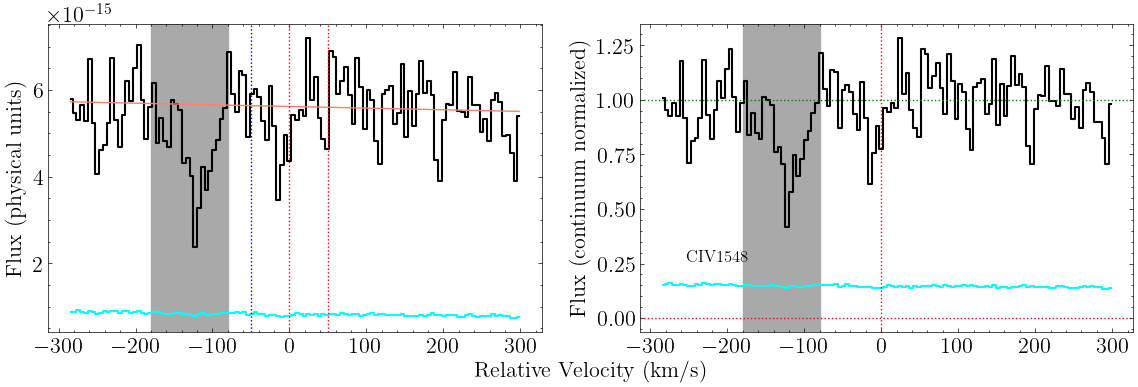

In [13]:
fig, ax = civ_1548_stis.plot_ion_transition_spec_cont()

In [14]:
civ_1548_stis.grab_ion_transition_lsf(lsf_fits_list)

Re-define variables

In [15]:
v = civ_1548_stis.v
err_std = civ_1548_stis.err_norm

In [16]:
b = 14

Define function for constructing a Voigt profile

In [17]:
def vp(v, logN, lsf_convolve=True):
    
    model = comp_model_spec_gen(v, np.array([[logN, b, 0]]), 
                                civ_1548_stis.wav0_rest, civ_1548_stis.f, civ_1548_stis.gamma, civ_1548_stis.A,
                                lsf_convolve,
                                civ_1548_stis.lsf, civ_1548_stis.v_lsf)[1]
    
    return model

Construct a mock profile to test convolution and measure the new FWHM

In [18]:
# Unconvolved and convolved profiles
mock_unconv = vp(v, 11.5, False)
mock_conv = vp(v, 11.5, True)

# Flux levels for FWHM in each profile
flux_fwhm_unconv = 1-0.5*(1-np.min(mock_unconv))
flux_fwhm_conv = 1-0.5*(1-np.min(mock_conv))

# Corresponding FWHM calculation
fwhm_unconv = 2*v[v>0][np.argmin(np.abs(mock_unconv[v>0]-flux_fwhm_unconv))]
fwhm_conv = 2*v[v>0][np.argmin(np.abs(mock_conv[v>0]-flux_fwhm_conv))]

In [19]:
np.sum(1-mock_conv), np.sum(1-mock_unconv)

(0.050227570232019625, 0.05022757029410607)

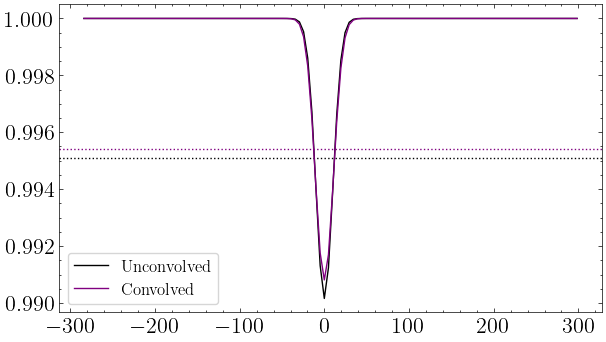

In [20]:
fig, ax = plt.subplots(1, figsize=(7,4))
ax.plot(v, mock_unconv, label='Unconvolved', color='black')
ax.axhline(flux_fwhm_unconv, color='black', linestyle=':')
ax.plot(v, mock_conv, label='Convolved', color='purple')
ax.axhline(flux_fwhm_conv, color='purple', linestyle=':')
ax.legend()

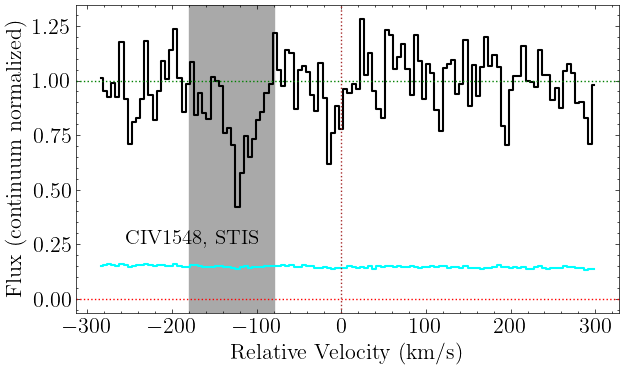

In [21]:
fig, ax = civ_1548_stis.plot_ion_transition_spec()
#ax.axvspan(xmin=-fwhm_conv, xmax=fwhm_conv, color='yellow', alpha=.1)

In [22]:
idx = (v>-fwhm_conv)&(v<fwhm_conv)
err_std = civ_1548_stis.err_norm

Run the Monte Carlo experiment

In [23]:
N_trials = 4000
logN_grid = np.arange(0, 14.1, 0.1)

In [24]:
model_grid = np.zeros((len(logN_grid), len(v)))

for i in range(len(logN_grid)):
    model_grid[i,:] = vp(v, logN_grid[i])

In [25]:
# For each logN for each trial, get Gaussian noise
noise_grid = np.zeros((N_trials, len(v)))

# For each spectral pixel
for k in range(len(v)):
    # Generate noise for all logN, for each trial
    noise_samples = np.random.normal(loc=1, scale=err_std[k], size=N_trials)
    # Save the reshaped noise in the larger grid
    noise_grid[:,k] = noise_samples

Evaluate $\chi^2$ for each grid point across all realizations of noise

In [27]:
chi_sq_grid = np.zeros((N_trials, len(logN_grid)))
chi_sq_act = np.zeros(len(logN_grid))

for i in range(N_trials):
    for j in range(len(logN_grid)):
        
        raw_spec = noise_grid[i,:][idx]
        model_spec = model_grid[j,:][idx]
        err_spec = err_std[idx]
        
        chi_sq_grid[i,j] = np.sum((raw_spec-model_spec)**2/err_spec**2)
        chi_sq_act[j] = np.sum((civ_1548_stis.flux_norm[idx]-model_spec)**2/err_spec**2)

Plot some realizations of the noise

In [28]:
logN_plot = 13.0
logN_idx = np.where(np.round(logN_grid, 1) == logN_plot)[0][0]

In [29]:
trials_indices = np.random.randint(low=0, high=N_trials, size=4)

Text(0, 0.5, 'Flux (continuum normalized)')

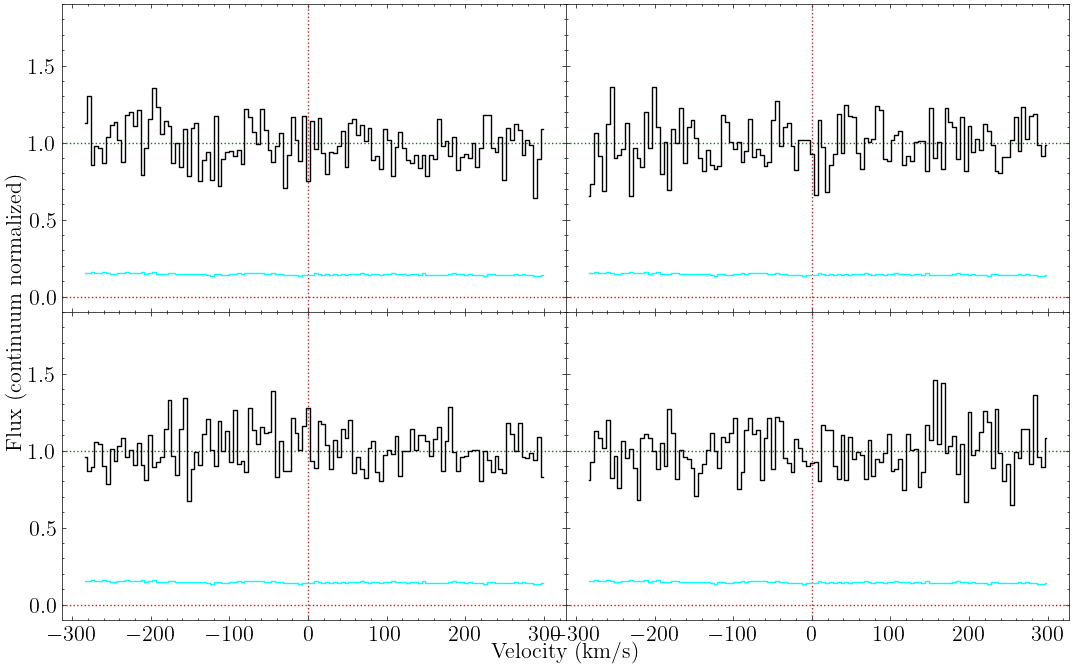

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(13,8), sharex=True, sharey=True)

axes[0,0].set_ylim(-0.1, 1.9)

for i in range(len(trials_indices)):
    
    ax = axes[i//2, i%2]
    ax.axvline(0, linestyle=':', color='brown')
    ax.axhline(0, linestyle=':', color='red')
    ax.axhline(1, linestyle=':', color='green')
    trial_idx = trials_indices[i]
    ax.step(v, noise_grid[trial_idx, :], where='mid')
    #ax.plot(v, model_grid[logN_idx, :], color='orangered', lw=2)
    ax.step(v, err_std, where='mid', color='cyan')
    #ax.axvspan(xmin=v[idx][0], xmax=v[idx][-1], color='yellow', alpha=.1)
    #ax.text(x=-280, y=1.7, s=r'$\chi^2 = $'+' {:.1f}'.format(chi_sq_grid[trial_idx, logN_idx]))
    
plt.subplots_adjust(wspace=0, hspace=0)   

ax_label = fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axes
ax_label.set_xticks([])
ax_label.set_yticks([])
ax_label.set_xlabel('Velocity (km/s)', labelpad=15) # Use argument `labelpad` to move label downwards.
ax_label.set_ylabel('Flux (continuum normalized)', labelpad=25)

Text(0, 0.5, 'Flux (continuum normalized)')

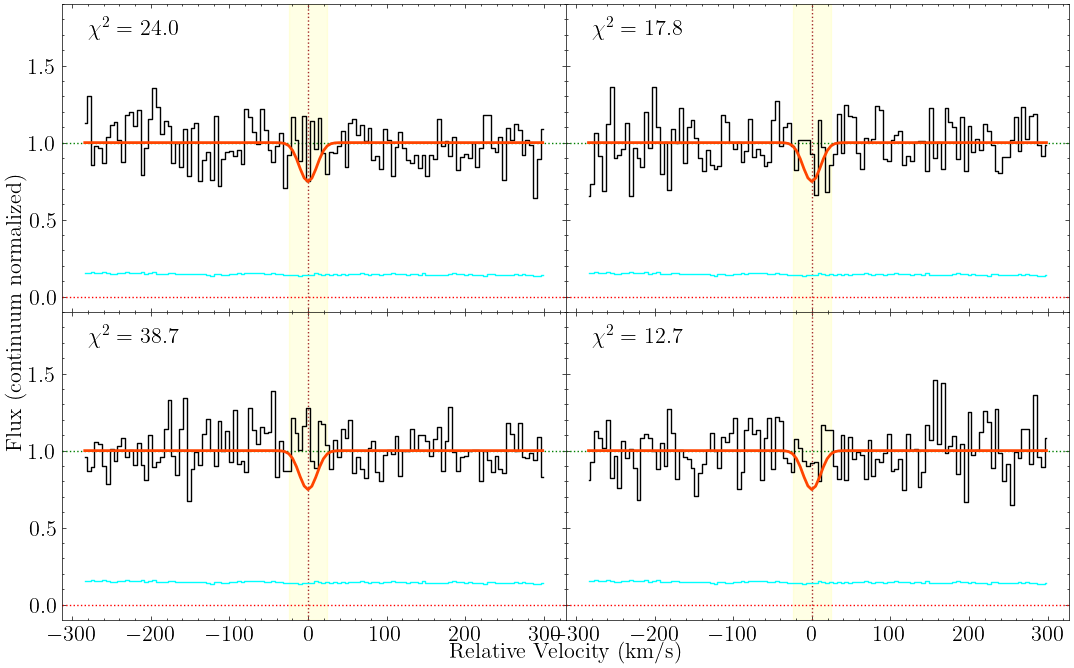

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(13,8), sharex=True, sharey=True)

axes[0,0].set_ylim(-0.1, 1.9)

for i in range(len(trials_indices)):
    
    ax = axes[i//2, i%2]
    ax.axvline(0, linestyle=':', color='brown')
    ax.axhline(0, linestyle=':', color='red')
    ax.axhline(1, linestyle=':', color='green')
    trial_idx = trials_indices[i]
    ax.step(v, noise_grid[trial_idx, :], where='mid')
    ax.plot(v, model_grid[logN_idx, :], color='orangered', lw=2)
    ax.step(v, err_std, where='mid', color='cyan')
    ax.axvspan(xmin=v[idx][0], xmax=v[idx][-1], color='yellow', alpha=.1)
    ax.text(x=-280, y=1.7, s=r'$\chi^2 = $'+' {:.1f}'.format(chi_sq_grid[trial_idx, logN_idx]))
    
plt.subplots_adjust(wspace=0, hspace=0)   

ax_label = fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axes
ax_label.set_xticks([])
ax_label.set_yticks([])
ax_label.set_xlabel('Relative Velocity (km/s)', labelpad=15) # Use argument `labelpad` to move label downwards.
ax_label.set_ylabel('Flux (continuum normalized)', labelpad=25)

Text(0, 0.5, 'Counts')

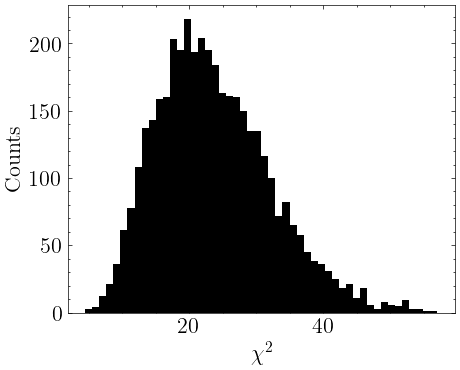

In [32]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.hist(chi_sq_grid[:, logN_idx], bins=50)
ax.set_xlabel(r'$\chi^2$')
ax.set_ylabel('Counts')

Plot the realizations

Text(0, 0.5, '$\\chi^2$')

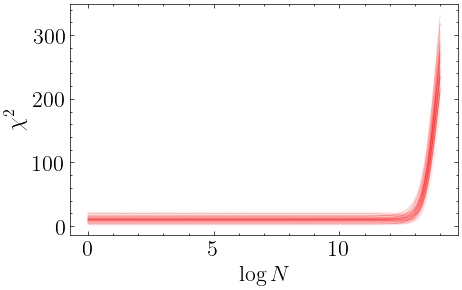

In [33]:
fig, ax = plt.subplots(1, figsize=(5,3))

for j in range(100):
    ax.plot(logN_grid, chi_sq_grid[j,:], lw=0.4, color='red', alpha=.1)

#ax.plot(logN_grid, chi_sq_mean, color='black', lw=2)
    
ax.set_xlabel(r'$\log N$')
ax.set_ylabel(r'$\chi^2$')

In [34]:
chi_sq_mean = np.mean(chi_sq_grid, axis=0)

In [35]:
chi_sq_th = np.zeros(len(chi_sq_mean))

for i in range(len(logN_grid)):
    
    chi_sq_th[i] = np.sum(((model_grid[i,:][idx]-1)/err_std[idx])**2)
    
chi_sq_th += len(v[idx])

Text(0, 0.5, '$\\chi^2$')

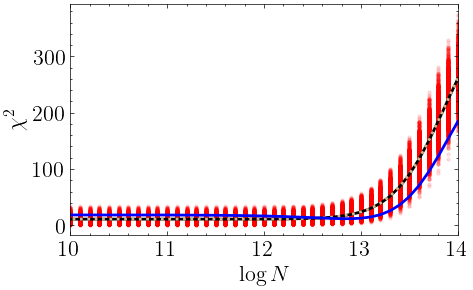

In [36]:
fig, ax = plt.subplots(1, figsize=(5,3))

for j in range(N_trials):
    ax.scatter(logN_grid, chi_sq_grid[j,:], s=5, color='red', alpha=.1)

ax.plot(logN_grid, chi_sq_mean, color='black', lw=2)
ax.plot(logN_grid, chi_sq_th, color='tan', lw=2, linestyle=':')
ax.plot(logN_grid, chi_sq_act, color='blue', lw=2)

ax.set_xlim(10,14)
ax.set_xlabel(r'$\log N$')
ax.set_ylabel(r'$\chi^2$')

In [57]:
0.2*np.mean(v[1:]-v[:-1])

0.9790651167091338

Text(0, 0.5, '$\\chi^2$')

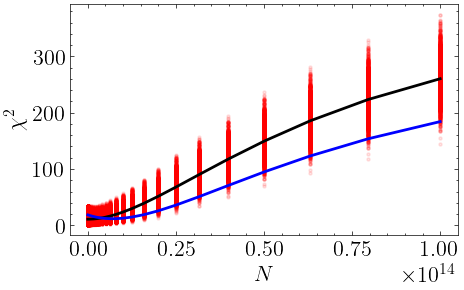

In [38]:
fig, ax = plt.subplots(1, figsize=(5,3))

for j in range(N_trials):
    ax.scatter(10**logN_grid, chi_sq_grid[j,:], s=5, color='red', alpha=.1)

ax.plot(10**logN_grid, chi_sq_mean, color='black', lw=2)
ax.plot(10**logN_grid, chi_sq_act, color='blue', lw=2)
#ax.plot(logN_grid, chi_sq_th, color='tan', lw=2, linestyle=':')

#ax.set_xlim(10,14)
ax.set_xlabel(r'$N$')
ax.set_ylabel(r'$\chi^2$')

Convert the average $\chi^2$ into probability

In [39]:
pdf = np.exp(-0.5*chi_sq_mean)
pdf_act = np.exp(-0.5*chi_sq_act)

Text(0, 0.5, 'PDF $ \\propto \\exp(-0.5 \\chi^2)$')

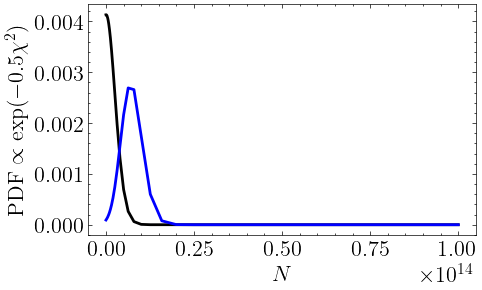

In [40]:
fig, ax = plt.subplots(1, figsize=(5,3))

ax.plot(10**logN_grid, pdf, color='black', lw=2)
ax.plot(10**logN_grid, pdf_act, color='blue', lw=2)
    
ax.set_xlabel(r'$N$')
ax.set_ylabel(r'PDF $ \propto \exp(-0.5 \chi^2)$')

Convert the PDF into a CDF

In [43]:
cdf = np.cumsum(pdf)/np.sum(pdf)
cdf_act = np.cumsum(pdf_act)/np.sum(pdf_act)

Text(0, 0.5, 'CDF')

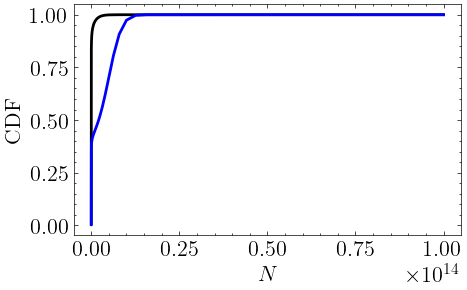

In [44]:
fig, ax = plt.subplots(1, figsize=(5,3))

ax.plot(10**logN_grid, cdf, color='black', lw=2)
ax.plot(10**logN_grid, cdf_act, color='blue', lw=2)
    
ax.set_xlabel(r'$N$')
ax.set_ylabel('CDF')

Get the upper limits

In [45]:
# Significance levels
# Sigma values taken from Gehrels 1986
cdf_1sig = 0.8413
cdf_2sig = 0.9772
cdf_3sig = 0.9987

In [50]:
ppf = interpolate.interp1d(x=cdf, y=10**logN_grid)
ppf_act = interpolate.interp1d(x=cdf_act, y=10**logN_grid)

In [51]:
logN_1sig_VP = np.round(np.log10(ppf([cdf_1sig])[0]), 1)
logN_2sig_VP = np.round(np.log10(ppf([cdf_2sig])[0]), 1)
logN_3sig_VP = np.round(np.log10(ppf([cdf_3sig])[0]), 1)

In [52]:
logN_1sig_VP, logN_2sig_VP, logN_3sig_VP

(10.4, 12.2, 12.7)

In [54]:
np.round(np.log10(ppf_act([cdf_1sig])[0]), 1), np.round(np.log10(ppf_act([cdf_2sig])[0]), 1), np.round(np.log10(ppf_act([cdf_3sig])[0]), 1)

(12.8, 13.0, 13.2)

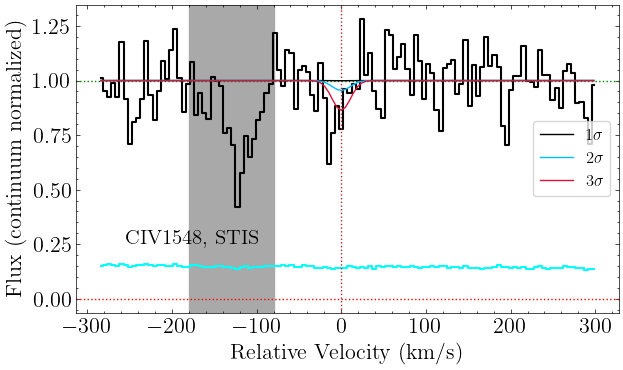

In [55]:
fig, ax = civ_1548_stis.plot_ion_transition_spec()
ax.plot(civ_1548_stis.v, vp(civ_1548_stis.v, logN_1sig_VP), lw=1, label=r'$1\sigma$')
ax.plot(civ_1548_stis.v, vp(civ_1548_stis.v, logN_2sig_VP), lw=1, label=r'$2\sigma$')
ax.plot(civ_1548_stis.v, vp(civ_1548_stis.v, logN_3sig_VP), lw=1, label=r'$3\sigma$')

ax.legend()

In [46]:
len(v[idx])

27

Compute corresponding upper limits using equivalent width

In [56]:
v_abs = v[idx]
err_abs = err_std[idx][:-1] # Excluding the last element is important to mimic integration

In [57]:
delta_lambda = np.mean(((v_abs[1:]-v_abs[:-1])*civ_1548_stis.wav0_rest/3e+5)*1e+3) # in mA
EW_1sig = np.sqrt(np.sum((err_abs*delta_lambda)**2))

In [58]:
N_1sig = (EW_1sig*1e-3/civ_1548_stis.wav0_rest)*(3e+8/(civ_1548_stis.wav0_rest*1e-10))*(2.654e-2*civ_1548_stis.f)**-1

In [59]:
logN_1sig_EW = np.round(np.log10(N_1sig),1)
logN_2sig_EW = np.round(np.log10(2*N_1sig),1)
logN_3sig_EW = np.round(np.log10(3*N_1sig),1)

In [60]:
logN_1sig_EW, logN_2sig_EW, logN_3sig_EW

(12.7, 13.0, 13.1)

We'll repeat the above experiment with different $b$ values and see how these upper limits evolve

In [53]:
b_grid = np.array([10, 20, 30, 40])

In [63]:
logN_2sig_VP_grid = np.array([12.1, 12.2, 12.3, 12.3])
logN_3sig_VP_grid = np.array([12.6, 12.7, 12.8, 12.9])

logN_2sig_EW_grid = np.array([12.6, 12.8, 12.9, 13.0])
logN_3sig_EW_grid = np.array([12.8, 13.0, 13.1, 13.1])

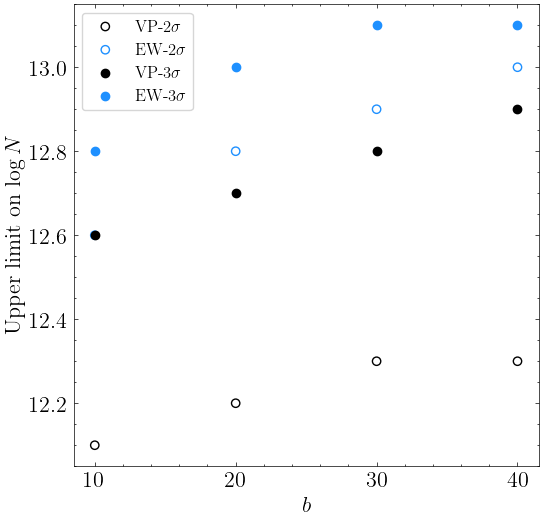

In [64]:
fig, ax = plt.subplots(1, figsize=(6,6))

ax.scatter(b_grid, logN_2sig_VP_grid, label=r'VP-$2 \sigma$', color='black', facecolor='none')
ax.scatter(b_grid, logN_2sig_EW_grid, label=r'EW-$2 \sigma$', color='dodgerblue', facecolor='none')

ax.scatter(b_grid, logN_3sig_VP_grid, label=r'VP-$3 \sigma$', color='black')
ax.scatter(b_grid, logN_3sig_EW_grid, label=r'EW-$3 \sigma$', color='dodgerblue')

ax.set_xlabel(r'$b$')
ax.set_ylabel(r'Upper limit on $\log N$')
ax.legend()